In [3]:
import pickle
import pandas as pd

In [4]:
model_path  = '../2_model_development/model_development_results_dict.pkl'
data_prefix = '../0_data/processed_data/'
non_feature_cols = ['SMILES', 'MP', 'Type', 'Ro5']
model_types = ['RF', 'XGB', 'LGB']

In [6]:
with open(model_path, 'rb') as f:
    model_development_results_dict = pickle.load(f)

In [13]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor


def shap_analysis(model, data):
    """
    Run SHAP analysis for a fitted RF, XGB, or LightGBM model.

    Parameters
    ----------
    model : fitted regressor (RandomForestRegressor, XGBRegressor, or LGBMRegressor)
    data  : pd.DataFrame – must contain non_feature_cols = ['SMILES', 'MP', 'Type', 'Ro5']

    Produces:
        - SHAP beeswarm summary plot (all features)
        - SHAP bar plot of mean |SHAP| (top 20 features)

    Returns
    -------
    result    : pd.DataFrame – copy of data with per-feature SHAP columns (shap_<feature>)
    explainer : shap.TreeExplainer
    """
    non_feature_cols = ['SMILES', 'MP', 'Type', 'Ro5']
    X = data.drop(columns=non_feature_cols)

    model_class = type(model).__name__

    # Choose the appropriate explainer
    if model_class in ('RandomForestRegressor', 'XGBRegressor', 'LGBMRegressor'):
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X)
    else:
        raise ValueError(
            f"Unsupported model type '{model_class}'. "
            "Expected RandomForestRegressor, XGBRegressor, or LGBMRegressor."
        )

    # ── Plot 1: Beeswarm summary (all features) ───────────────────────
    plt.figure()
    shap.summary_plot(shap_values, X, plot_type='dot', show=False)
    plt.title(f'SHAP Beeswarm Summary — {model_class}', fontsize=13)
    plt.tight_layout()
    plt.show()

    # ── Plot 2: Mean |SHAP| bar chart (top 20) ────────────────────────
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    top20_idx      = np.argsort(mean_abs_shap)[::-1][:20]
    top20_features = X.columns[top20_idx]
    top20_values   = mean_abs_shap[top20_idx]

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(top20_features[::-1], top20_values[::-1], color='steelblue', edgecolor='white')
    ax.set_xlabel('Mean |SHAP value|', fontsize=12)
    ax.set_title(f'Top 20 Feature Importances (SHAP) — {model_class}', fontsize=13)
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

    # ── Attach SHAP values back to data ───────────────────────────────
    shap_df = pd.DataFrame(shap_values, columns=[f'shap_{c}' for c in X.columns],
                           index=data.index)
    result = pd.concat([data, shap_df], axis=1)

    return result, explainer


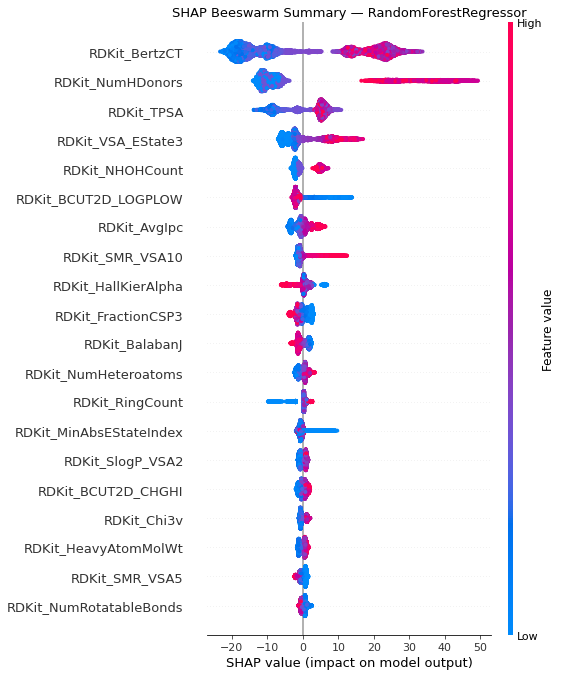

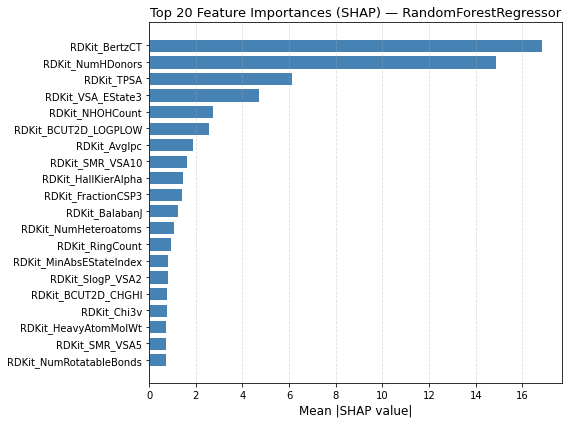

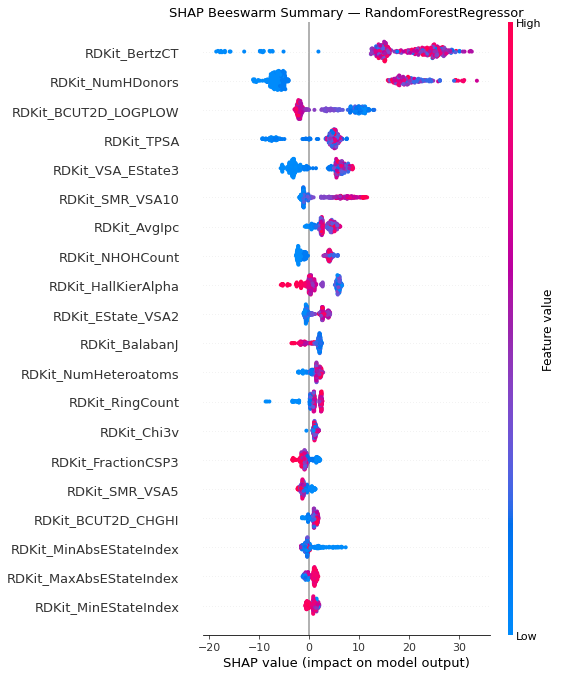

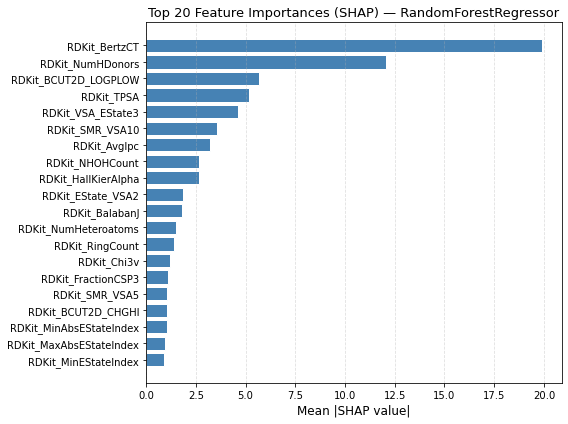

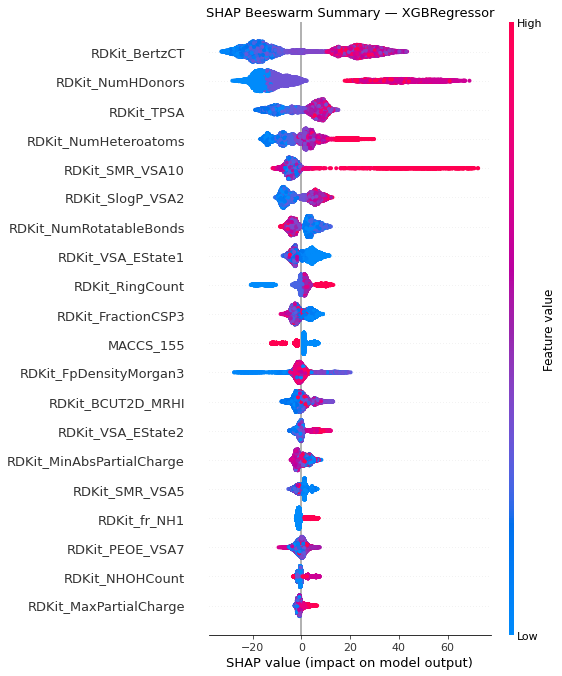

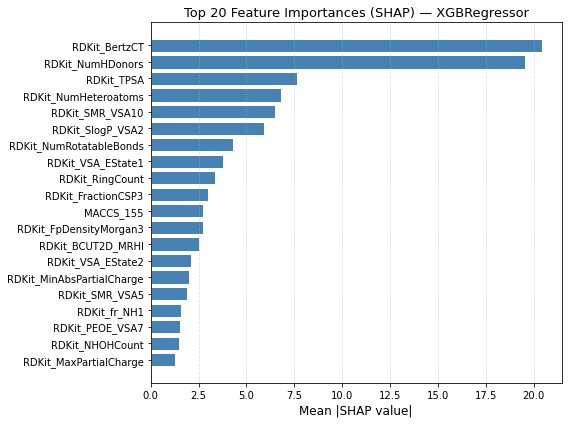

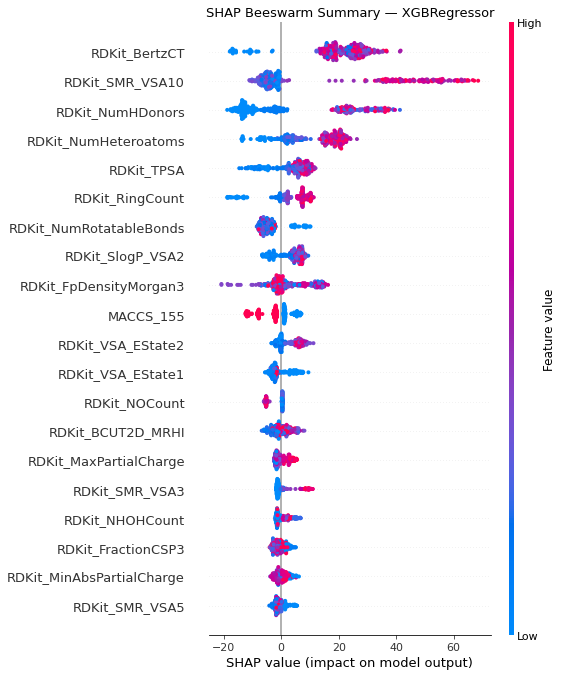

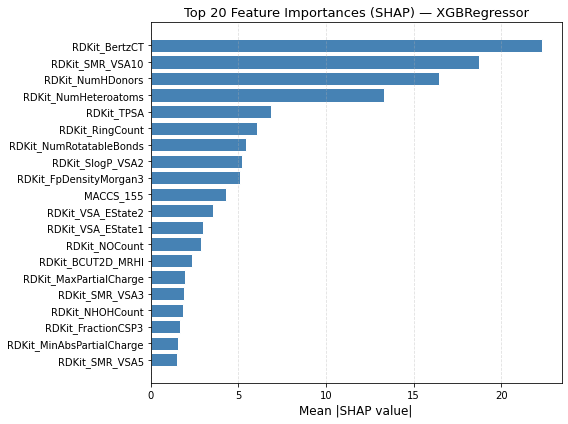

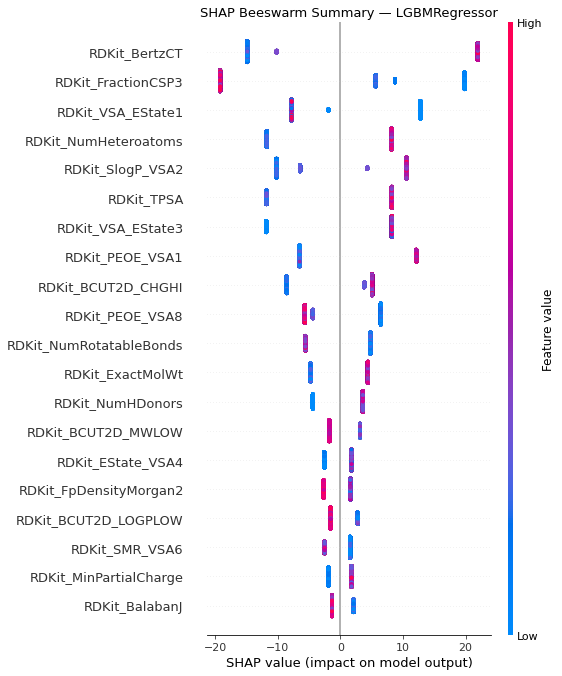

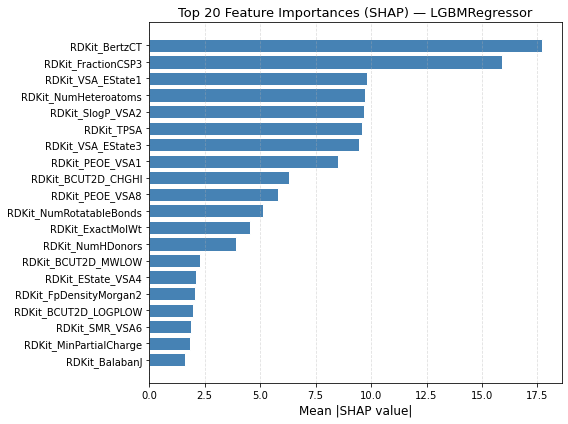

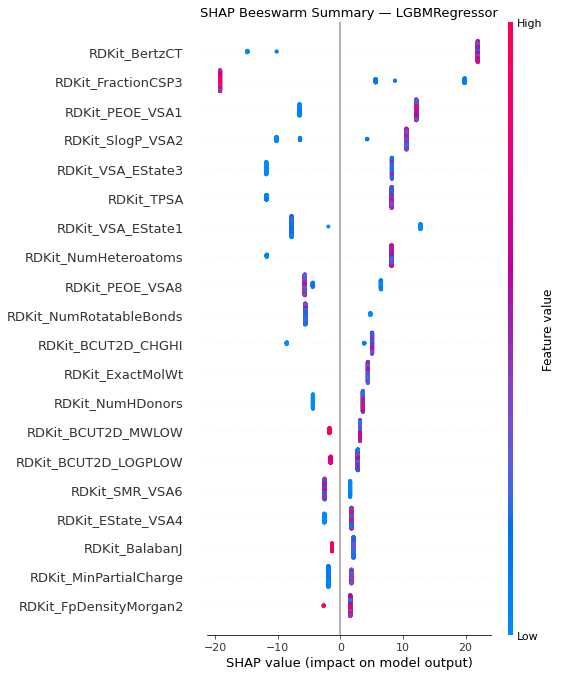

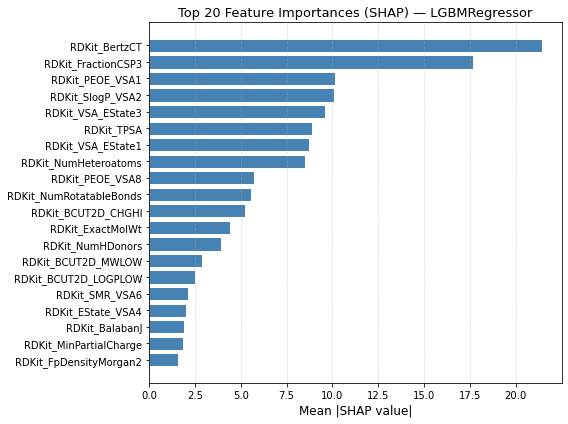

In [18]:
for model_name in model_types:
    for data_type in ['Ro5', 'bRo5']:

        model = model_development_results_dict[model_name]['best_model_info']['model']
        all_data = pd.read_parquet(data_prefix + f"data_with_selected_features_{model_name}_scaled.parquet")

        if data_type == 'Ro5':
            data = all_data[all_data['Ro5'] == 1].copy()
        else:
            data = all_data[all_data['Ro5'] == 0].copy()

        x,y = shap_analysis(model, data)